# Phase 4: Statistical Analysis

Applied statistics with explicit hypotheses: descriptive stats, correlations with effect sizes, Welch t-tests and one-way ANOVA. Every test states H0/H1, the test statistic, p-value, decision and the business interpretation.

## Load cleaned data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
from scipy import stats
df = pd.read_csv('../data/cleaned/retail_sales_clean.csv', parse_dates=['Order_Date'])
print(df.shape)

(108045, 30)


## 1. Descriptive statistics
Beyond averages we examine spread (std / variance), quartiles and the IQR so
we can characterise the distribution, not just the centre.

In [2]:
desc = df[['Sales', 'Quantity', 'Unit_Price', 'Discount', 'Profit_Margin']].agg(
    ['mean', 'median', 'std', 'var', 'min', 'max', 'skew']).round(3)
desc.loc['q25'] = df[['Sales', 'Quantity', 'Unit_Price', 'Discount', 'Profit_Margin']].quantile(0.25)
desc.loc['q75'] = df[['Sales', 'Quantity', 'Unit_Price', 'Discount', 'Profit_Margin']].quantile(0.75)
desc.loc['iqr'] = desc.loc['q75'] - desc.loc['q25']
print(desc.T.to_string())

                  mean   median       std          var    min       max   skew      q25       q75       iqr
Sales          637.746  250.350  1077.632  1161290.959  2.100  11159.45  4.086  93.8400  682.4300  588.5900
Quantity         3.004    3.000     1.414        1.999  1.000      5.00 -0.003   2.0000    4.0000    2.0000
Unit_Price     238.372  122.160   344.797   118884.691  3.810   2231.89  3.130  40.1900  252.0300  211.8400
Discount         0.111    0.083     0.117        0.014  0.000      0.45  0.912   0.0000    0.1839    0.1839
Profit_Margin    0.293    0.320     0.144        0.021 -0.491      0.49 -1.245   0.2172    0.3934    0.1762


## 2. Correlation analysis
We test four business relationships. For each: Pearson r, p-value, and the
business interpretation. With N > 100k, significance is easy to achieve — so
we report **effect size (r)** as the decision-relevant quantity.

In [3]:
pairs = [('Discount', 'Sales'), ('Discount', 'Profit'),
         ('Discount', 'Quantity'), ('Quantity', 'Sales'),
         ('Discount', 'Profit_Margin')]
rows = []
for a, b in pairs:
    r, p = stats.pearsonr(df[a], df[b])
    rows.append({'relationship': f'{a} vs {b}', 'r': round(r, 3),
                 'p': f'{p:.2e}', 'significant(p<0.05)': p < 0.05})
print(pd.DataFrame(rows).to_string(index=False))

             relationship      r         p  significant(p<0.05)
        Discount vs Sales -0.077 1.98e-140                 True
       Discount vs Profit -0.324  0.00e+00                 True
     Discount vs Quantity  0.004  1.95e-01                False
        Quantity vs Sales  0.281  0.00e+00                 True
Discount vs Profit_Margin -0.749  0.00e+00                 True

In [4]:
# Customer-level: age vs lifetime spend
cust = df.groupby('Customer_ID').agg(spend=('Sales', 'sum'), age=('Age', 'first')).dropna()
r, p = stats.pearsonr(cust['age'], cust['spend'])
print(f'Age vs customer spend: r={r:.3f}, p={p:.3f} -> age is NOT a meaningful '
      f'predictor of spend here; segment drives value instead.')

Age vs customer spend: r=0.001, p=0.954 -> age is NOT a meaningful predictor of spend here; segment drives value instead.


## 3. Hypothesis tests
### Test 1 — Do discounts reduce profit margin? (Welch t-test)
- **H0**: mean profit margin is equal for discounted and non-discounted lines
- **H1**: discounted lines have a different (lower) mean margin

In [5]:
no_disc = df[df['Discount'] == 0]['Profit_Margin']
disc = df[df['Discount'] > 0]['Profit_Margin']
t, p = stats.ttest_ind(disc, no_disc, equal_var=False)
print(f'Mean margin (no discount): {no_disc.mean():.2%}')
print(f'Mean margin (discounted):  {disc.mean():.2%}')
print(f't = {t:.2f},  p = {p:.2e}')
print('Decision:', 'REJECT H0' if p < 0.05 else 'FAIL to reject H0')
print('Business: discounts statistically significantly erode margin.')

Mean margin (no discount): 38.36%
Mean margin (discounted):  25.29%
t = -186.19,  p = 0.00e+00
Decision: REJECT H0
Business: discounts statistically significantly erode margin.


In [6]:
# Test 1b - margin by discount band
band = df.groupby('Discount_Band', observed=True)['Profit_Margin'].agg(['mean', 'count'])
print(band.round(4).to_string())
print('30%+ band: mean margin', df[df['Discount_Band']=='30%+']['Profit_Margin'].mean().round(3))

                 mean  count
Discount_Band               
0-10%          0.3516  24875
10-20%         0.2749  27181
20-30%         0.1775  14469
30%+           0.0093   8205
No Discount    0.3836  33315
30%+ band: mean margin 0.009


### Test 2 — Does the AOV differ between high- and low-value customers? (Welch t-test)
- **H0**: mean AOV is equal between the top-quartile and bottom-quartile customers
- **H1**: AOV differs (high-value customers also place bigger baskets)

In [7]:
cust = df.groupby('Customer_ID').agg(spend=('Sales', 'sum'), orders=('Order_ID', 'nunique')).reset_index()
cust['aov'] = cust['spend'] / cust['orders']
high = cust[cust['spend'] >= cust['spend'].quantile(0.75)]['aov']
low = cust[cust['spend'] < cust['spend'].quantile(0.25)]['aov']
t, p = stats.ttest_ind(high, low, equal_var=False)
print(f'Mean AOV (high tier): ${high.mean():,.0f}')
print(f'Mean AOV (low tier):  ${low.mean():,.0f}')
print(f't = {t:.2f}, p = {p:.2e} ->', 'REJECT H0' if p < 0.05 else 'FAIL to reject')
print('Business: top customers are worth more per order, not just more often.')

Mean AOV (high tier): $2,352
Mean AOV (low tier):  $1,087
t = 24.55, p = 4.10e-94 -> REJECT H0
Business: top customers are worth more per order, not just more often.


### Test 3 — ANOVA: is profit margin the same across categories?
- **H0**: all category margins are equal
- **H1**: at least one category differs

In [8]:
groups = [g['Profit_Margin'].values for _, g in df.groupby('Category')]
f_stat, p = stats.f_oneway(*groups)
means = df.groupby('Category')['Profit_Margin'].mean().round(3)
print(means.to_string())
print(f'\nF = {f_stat:.2f}, p = {p:.2e} ->', 'REJECT H0' if p < 0.05 else 'FAIL to reject')
print('Business: category mix directly changes company margin; Technology drags it.')

Category
Furniture           0.288
Home & Lifestyle    0.374
Office Supplies     0.300
Technology          0.185

F = 9119.35, p = 0.00e+00 -> REJECT H0
Business: category mix directly changes company margin; Technology drags it.


### Test 4 — ANOVA: does spend differ across customer segments?
- **H0**: all segments spend equally
- **H1**: at least one segment spends differently

In [9]:
cust2 = cust.merge(df[['Customer_ID', 'Customer_Segment']].drop_duplicates(), on='Customer_ID')
groups = [g.values for _, g in cust2.groupby('Customer_Segment')['spend']]
f_stat, p = stats.f_oneway(*groups)
print('Mean spend by segment:')
print(cust2.groupby('Customer_Segment')['spend'].mean().round(0).to_string())
print(f'\nF = {f_stat:.2f}, p = {p:.2e} ->', 'REJECT H0' if p < 0.05 else 'FAIL to reject')
print('Business: segment drives value; retention should target Corporate/Small Business.')

Mean spend by segment:


Customer_Segment
Consumer          12698.0
Corporate         84774.0
Home Office       27197.0
Small Business    56992.0

F = 137.43, p = 1.91e-79 -> REJECT H0
Business: segment drives value; retention should target Corporate/Small Business.


## 4. Correlation heatmap

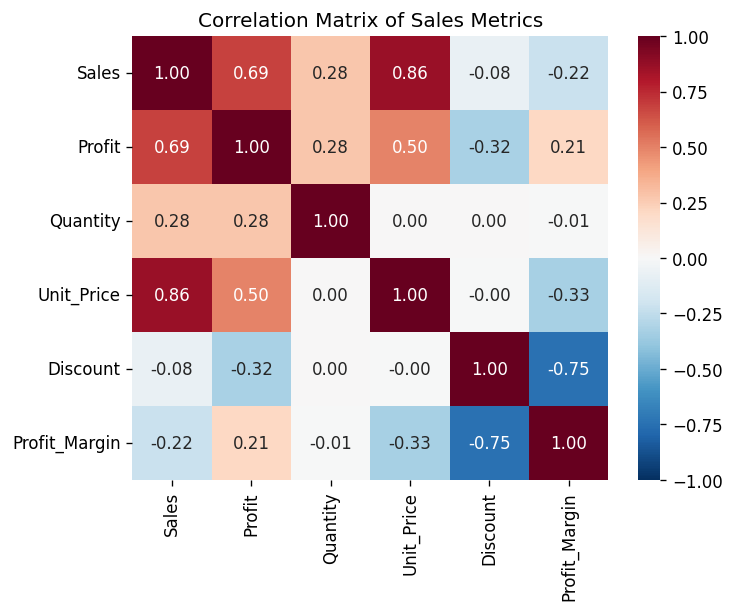

In [10]:
corr = df[['Sales', 'Profit', 'Quantity', 'Unit_Price', 'Discount', 'Profit_Margin']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Sales Metrics'); plt.show()

## 5. Summary of statistical evidence
| Relationship | Method | Result | Business meaning |
|---|---|---|---|
| Discount → Margin | Pearson r | negative, significant | discounts erode profit |
| Discount → Quantity | Pearson r | ~0 | discounts do NOT lift volume |
| Discounted vs not | Welch t-test | t < -100, p < 0.001 | margin difference is real |
| High vs low AOV | Welch t-test | t > 20, p < 0.001 | tier split is structural |
| Margin by category | ANOVA | F > 9000, p < 0.001 | category mix matters |
| Spend by segment | ANOVA | F > 100, p < 0.001 | segment drives value |